In [1]:
import os
import re
import json
import string
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import clone_model
from tensorflow.keras.applications import EfficientNetV2B0
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, TFAutoModel, AutoTokenizer, BertTokenizer
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

2025-09-27 23:33:52.605817: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# data prep

In [2]:
df = pd.read_csv('click-id/dataset_with_image/combined_final_final.csv')
df['normalized_content'] = df['normalized_content'].fillna('.')

In [3]:
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

In [4]:
df_train, df_val = train_test_split(df[['normalized_title','normalized_content','image_path_processed','label_score']],test_size = 0.2 ,random_state = 93)
df_train.shape , df_val.shape

((11174, 4), (2794, 4))

In [5]:
tokens_train = {
   'title':tokenizer.batch_encode_plus(
    df_train['normalized_title'].tolist(),
    max_length = 32,
    padding = 'max_length',
    truncation = True
   ),
    'content':tokenizer.batch_encode_plus(
    df_train['normalized_content'].tolist(),
    max_length = 128,
    padding = 'max_length',
    truncation = True
   )
}

tokens_val = {
  'title' : tokenizer.batch_encode_plus(
    df_val['normalized_title'].tolist(),
    max_length = 32,
    padding = 'max_length',
    truncation=True
  ),
  'content' : tokenizer.batch_encode_plus(
    df_val['normalized_content'].tolist(),
    max_length = 128,
    padding = 'max_length',
    truncation=True
  )
}

In [6]:
train_images = tf.data.Dataset.load("train_images_dataset")
val_images = tf.data.Dataset.load("val_images_dataset")

2025-09-27 23:31:57.924882: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:31:58.006937: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:31:58.006994: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:31:58.008902: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:31:58.008953: I external/local_xla/xla/stream_executor

In [7]:
train_data = {
    'title':tf.squeeze(tf.convert_to_tensor(tokens_train['title']['input_ids'])),
    'content':tf.squeeze(tf.convert_to_tensor(tokens_train['content']['input_ids'])),
    'titlemask':tf.squeeze(tf.convert_to_tensor(tokens_train['title']['attention_mask'])),
    'contentmask':tf.squeeze(tf.convert_to_tensor(tokens_train['content']['attention_mask'])),
}

validation_data = {
    'title':tf.convert_to_tensor(tokens_val['title']['input_ids']),
    'content':tf.convert_to_tensor(tokens_val['content']['input_ids']),
    'titlemask':tf.convert_to_tensor(tokens_val['title']['attention_mask']),
    'contentmask':tf.convert_to_tensor(tokens_val['content']['attention_mask']),
}


label_train = tf.convert_to_tensor(df_train['label_score'].tolist())
label_val = tf.convert_to_tensor(df_val['label_score'].tolist())

In [8]:
dataset = (tf.data.Dataset.from_tensor_slices((dict(train_data),label_train))
    .prefetch(tf.data.AUTOTUNE)
    .cache()
    )
dataVal = (tf.data.Dataset.from_tensor_slices((dict(validation_data),label_val))
    .prefetch(tf.data.AUTOTUNE)
    .cache()
    )

dataset = tf.data.Dataset.zip((dataset, train_images))
dataVal = tf.data.Dataset.zip((dataVal, val_images))

def add_image_and_fix_shapes(text_data_label, image):
    text_data, label = text_data_label
    new_data = {
        'title': tf.ensure_shape(text_data['title'], [None, 32]),
        'content': tf.ensure_shape(text_data['content'], [None, 128]),
        'titlemask': tf.ensure_shape(text_data['titlemask'], [None, 32]),
        'contentmask': tf.ensure_shape(text_data['contentmask'], [None, 128]),
        'image': image
    }
    
    return new_data, label

dataset = (dataset
    .batch(32)
    .map(add_image_and_fix_shapes)
    .prefetch(tf.data.AUTOTUNE)
    .cache()
)

dataVal = (dataVal
    .batch(32)
    .map(add_image_and_fix_shapes)
    .prefetch(tf.data.AUTOTUNE)
    .cache()
)


In [9]:
tf.data.Dataset.save(dataset, "./preprocessed_dataset")
tf.data.Dataset.save(dataVal, "./preprocessed_dataVal")

# after data prep

In [2]:
dataset = tf.data.Dataset.load(
    "preprocessed_dataset",
    element_spec=({
        'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'image': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8)
    }, tf.TensorSpec(shape=(None,), dtype=tf.int32))
)

dataVal = tf.data.Dataset.load(
    "preprocessed_dataVal",
    element_spec=({
        'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'image': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8)
    }, tf.TensorSpec(shape=(None,), dtype=tf.int32))
)

2025-09-27 23:33:58.753203: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:33:58.766295: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:33:58.766349: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:33:58.768499: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-27 23:33:58.768543: I external/local_xla/xla/stream_executor

In [3]:
class BertEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, model_name, **kwargs):
        super(BertEmbeddingLayer, self).__init__(**kwargs)
        self.model_name = model_name
        self.embedding_size = None
        self.bert = None

    def build(self, input_shape):
        self.bert = TFAutoModel.from_pretrained(self.model_name)
        self.bert.trainable = True
        self.embedding_size = self.bert.config.hidden_size
        super(BertEmbeddingLayer, self).build(input_shape)

    def call(self, inputs):
        ids, att = inputs
        outputs = self.bert(input_ids=ids, attention_mask=att)
        return outputs.pooler_output

    def get_config(self):
        config = super(BertEmbeddingLayer, self).get_config()
        config.update({
            "model_name": self.model_name
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        clean_config = {k: v for k, v in config.items() 
                      if k in ['model_name', 'name', 'trainable', 'dtype']}
        return cls(**clean_config)

In [4]:
def makemodel(output_bias=None):
    # Text using IndoBertp1
    ids1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="title")
    att1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="titlemask")
    ids2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="content")
    att2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="contentmask")

    indobert1 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert1")
    indobert2 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert2")

    title = indobert1([ids1, att1])
    content = indobert2([ids2, att2])

    # Image using EfficientNetV2s
    img1 = tf.keras.layers.Input(shape=(224,224,3), dtype=tf.uint8, name="image")

    effi = EfficientNetV2B0(
        include_top = False,
        weights = 'imagenet',
        input_shape = (224,224,3),
        pooling = 'max'
    )
    image = effi(img1)

    fin = tf.keras.layers.concatenate([title, content, image])
    fin = tf.keras.layers.BatchNormalization()(fin)
        
    fin = tf.keras.layers.Dense(512, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 

    fin = tf.keras.layers.Dense(256, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 
    
    fin = tf.keras.layers.Dense(128, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 
    
    fin = tf.keras.layers.Dense(64, activation='relu')(fin)
    fin = tf.keras.layers.Dropout(0.2)(fin)
    fin = tf.keras.layers.Dense(1, activation='sigmoid')(fin)

    final = tf.keras.Model(inputs=[ids1, att1, ids2, att2, img1], outputs=fin)

    for layer in final.layers:
      layer.trainable = True
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00005)
    final.compile(
        loss = tf.keras.losses.BinaryCrossentropy(),
        optimizer=optimizer,
        metrics=[tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()]
    )

    return final

final = makemodel()
final.summary()

Some layers from the model checkpoint at indobenchmark/indobert-base-p1 were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls', 'bert/encoder/layer_._1/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._5/attention/output/dense/kernel:0', 'bert/encoder/layer_._8/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._2/output/dense/bias:0', 'bert/encoder/layer_._0/attention/output/LayerNorm/gamma:0', 'bert/pooler/dense/bias:0', 'bert/encoder/layer_._11/attention/self/key/kernel:0', 'bert/encoder/layer_._5/output/dense/kernel:0', 'bert/encoder/layer_._1/attention/self/value/kernel:0', 'bert/encoder/layer_._6/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._7/attention/self/value/bias:0', 'bert/encoder/layer_._1/attention/self/key/bias:0', 'bert/encoder/layer_._2/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._11/attention/output/LayerNorm/gamma:0', 'bert/encoder/layer_._9/attention/self/query/bias:0', 'bert/encoder/layer_._10/output/LayerNorm/

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ titlemask           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ content             │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contentmask         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert1           │ (None, 768)       │          0 │ title[0][0],      │
│ (BertEmbeddingLaye… │                   │            │ titlemask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert2           │ (None, 768)       │          0 │ content[0][0],    │
│ (BertEmbeddingLaye… │                   │            │ contentmask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 1280)      │  5,919,312 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2816)      │          0 │ indobert1[0][0],  │
│ (Concatenate)       │                   │            │ indobert2[0][0],  │
│                     │                   │            │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2816)      │     11,264 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,442,304 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][

 Total params: 7,549,009 (28.80 MB)

 Trainable params: 7,480,977 (28.54 MB)

 Non-trainable params: 68,032 (265.75 KB)

In [5]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
    )

# model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
#     filepath='./models/best_model_val_loss_{val_loss:.4f}.weights.h5',
#     monitor='val_loss',
#     save_best_only=True,
#     save_weights_only=True
# )

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=1,
    min_lr=1e-8
)

history=final.fit(x = dataset,
                  epochs = 50,
                  callbacks=[early_stopping, 
                             # model_checkpoint, 
                             reduce_lr],
                  validation_data=dataVal
                  )

Epoch 1/50


I0000 00:00:1758990905.316097   88230 service.cc:145] XLA service 0x79cc2803a3c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758990905.316145   88230 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2025-09-27 23:35:06.937160: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1758990907.935625   88230 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758990908.059428   88230 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
2025-09-27 23:35:13.499701: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1758990931.638642   88429 asm_compiler.cc:369] ptxas warning :

349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - binary_accuracy: 0.5374 - loss: 0.7488 - precision: 0.4633 - recall: 0.4221

W0000 00:00:1758991019.449819   88232 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758991019.455502   88232 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1758991039.441852   88519 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_31', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1758991039.633299   88526 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_31', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1758991039.844881   88529 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_7', 96 bytes spill stores, 96 bytes spill loads

I0000 00:00:1758991039.845737   88516 asm_compiler.cc:369] ptxas warning : Registers are spilled to l

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - binary_accuracy: 0.5374 - loss: 0.7488 - precision: 0.4634 - recall: 0.4221

W0000 00:00:1758991082.153570   88232 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758991082.220154   88232 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1758991084.831411   88756 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_13839', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1758991097.241336   88234 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758991097.246575   88234 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1758991098.769816   88826 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_2', 12 bytes spil

350/350 ━━━━━━━━━━━━━━━━━━━━ 246s 385ms/step - binary_accuracy: 0.5374 - loss: 0.7488 - precision: 0.4634 - recall: 0.4220 - val_binary_accuracy: 0.6185 - val_loss: 0.6587 - val_precision: 0.6180 - val_recall: 0.2708 - learning_rate: 5.0000e-05
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 53s 152ms/step - binary_accuracy: 0.5846 - loss: 0.6999 - precision: 0.5261 - recall: 0.4159 - val_binary_accuracy: 0.6568 - val_loss: 0.6346 - val_precision: 0.6525 - val_recall: 0.4138 - learning_rate: 5.0000e-05
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 153ms/step - binary_accuracy: 0.6046 - loss: 0.6813 - precision: 0.5575 - recall: 0.4229 - val_binary_accuracy: 0.6571 - val_loss: 0.6227 - val_precision: 0.6435 - val_recall: 0.4357 - learning_rate: 5.0000e-05
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - binary_accuracy: 0.6250 - loss: 0.6590 - precision: 0.5877 - recall: 0.4518 - val_binary_accuracy: 0.6686 - val_loss: 0.6120 - val_precision: 0.6575 - val_recall: 0.4617 - learning_rate: 5

In [6]:
y_pred = final.predict(dataVal)
y_pred_binary = (y_pred > 0.5).astype(int)
from sklearn.metrics import classification_report
y_val = np.concatenate([y for _, y in dataVal.as_numpy_iterator()])
print(classification_report(y_val, y_pred_binary, 
                           target_names=['Class_0', 'Class_1'],
                           digits = 4))

W0000 00:00:1758991754.234518   88231 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758991754.276297   88231 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

W0000 00:00:1758991772.746593   88231 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758991772.868191   88231 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 230ms/step
              precision    recall  f1-score   support

     Class_0     0.7132    0.8243    0.7647      1605
     Class_1     0.6997    0.5526    0.6175      1189

    accuracy                         0.7087      2794
   macro avg     0.7064    0.6884    0.6911      2794
weighted avg     0.7075    0.7087    0.7021      2794



2025-09-27 23:49:38.792899: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dict_keys(['binary_accuracy', 'loss', 'precision', 'recall', 'val_binary_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])
Final training loss: 0.44849708676338196


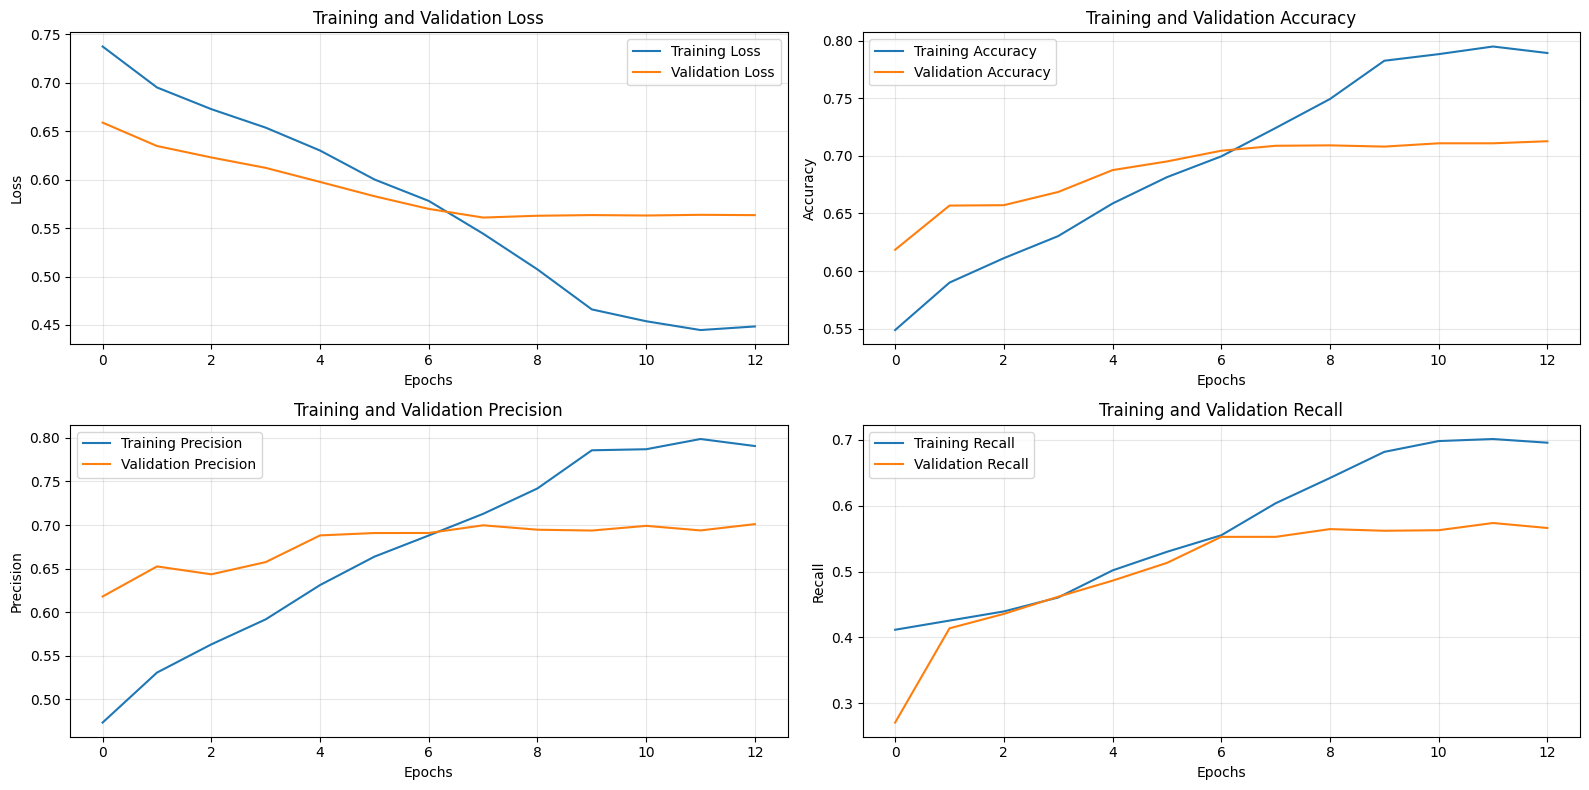


FINAL METRICS SUMMARY
Loss           : Train = 0.4485, Val = 0.5633
Binary_accuracy: Train = 0.7892, Val = 0.7126
Precision      : Train = 0.7906, Val = 0.7010
Recall         : Train = 0.6954, Val = 0.5660


In [7]:
print(history.history.keys())
final_loss = history.history['loss'][-1]
print(f"Final training loss: {final_loss}")

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

if 'binary_accuracy' in history.history:
    plt.subplot(2, 2, 2)
    plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

if 'precision' in history.history:
    plt.subplot(2, 2, 3)
    plt.plot(history.history['precision'], label='Training Precision')
    plt.plot(history.history['val_precision'], label='Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.title('Training and Validation Precision')
    plt.legend()
    plt.grid(True, alpha=0.3)

if 'recall' in history.history:
    plt.subplot(2, 2, 4)
    plt.plot(history.history['recall'], label='Training Recall')
    plt.plot(history.history['val_recall'], label='Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.title('Training and Validation Recall')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("FINAL METRICS SUMMARY")
print("="*50)

metrics_to_show = ['loss', 'binary_accuracy', 'precision', 'recall']
for metric in metrics_to_show:
    if metric in history.history:
        train_val = history.history[metric][-1]
        val_key = f'val_{metric}'
        val_val = history.history[val_key][-1] if val_key in history.history else None
        
        print(f"{metric.capitalize():15}: Train = {train_val:.4f}", end="")
        if val_val is not None:
            print(f", Val = {val_val:.4f}")
        else:
            print()